In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import pickle

from difflib import SequenceMatcher
from dateutil.relativedelta import relativedelta
from datetime import date

from sklearn import model_selection, linear_model
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
import xgboost as xgb # pip install if not available
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, fbeta_score, classification_report, make_scorer

In [3]:
import os
print(os.getcwd())

C:\Users\Dian\OneDrive\Documents\SMU MITB AI\Academic Term\Term 1 (Jan 2026 to Apr 2026)\CS610 Applied Machine Learning\Project\CS610_Interpol\Pillar 3 (Biometric Prediction)


In [4]:
pd.set_option('display.max_columns', None)

## Reading Synthetic and Sanctions Data
* Select relevant features and drop duplicates

In [5]:
synthetic_client = pd.read_csv('../synthetic_data_generation/synthetic_client_data.csv')
sanctions = pd.read_csv('../synthetic_data_generation/processed/mega_sanctions_final.csv')
display(synthetic_client)
display(sanctions)

,client_id,full_name,date_of_birth,gender,nationality_code,height_m,weight_kg,hair_color,eye_color,match_label,matched_sanction_id
0,C000001,AARON MACARONE MOTSA,1959-09-29,F,py,1.65,0.0,NaN,NaN,0,interpol-red-2015-42000
1,C000002,ASIA DAKHKILGOVA,1988-12-10,M,ru,NaN,0.0,NaN,NaN,0,interpol-red-2019-44001
2,C000003,ALEKSANDR PULGAR,1991-02-23,M,np,NaN,0.0,NaN,BRO,0,interpol-red-2016-64765
3,C000004,TIMUR ABDURAKHMANOV,NaN,M,co,1.75,0.0,BLA,NaN,0,interpol-red-2021-19548
4,C000005,SIMEON MIHAYLOV HRISTOV,1994-11-04,M,tr,1.72,NaN,NaN,BRO,0,interpol-red-2017-162255
...,...,...,...,...,...,...,...,...,...,...,...
99995,C099996,THI HIEN DINH,1961-02-21,F,vn,NaN,NaN,BLA,BRO,1,interpol-red-2017-144705
99996,C099997,RASUL HERNANDEZ,1988-10-08,F,vn,NaN,82.0,NaN,NaN,0,interpol-red-2016-38988
99997,C099998,MAGOMED-ALI ISRAILOV,1985-07-12,M,mx,NaN,NaN,NaN,NaN,0,NK-mB3Pictdsd6M363Nxp4yeS
99998,C099999,RAFAEL MARTÍNEZ AGURETA,1961-08-08,M,sv,NaN,0.0,NaN,NaN,1,interpol-red-2021-79552


,id,name,aliases,birth_date,hairColor,height,eyeColor,GENDER,age_at_first_seen,days_at_large,age_today,age_at_last_seen,countries,Label,address,sanctions_clean,phones,emails,schema,program_ids,dataset,first_seen,last_seen,last_change,entity_id,weight,languages_spoken_ids,distinguishing_marks,_links.self.href,_links.images.href,_links.thumbnail.href,network_entity_id,network_name
0,NK-224TRezPqwzhQZ37exWxtX,SANAVBARI NIKITENKO,NaN,1992-06-28,OTHD,NaN,OTHD,F,31.7,667,33,32.7,ru,Russia,kofarnikhon town,"""participation in the activity of a terrorist ...",NaN,NaN,Person,INTERPOL-RN,INTERPOL Red Notices,2024-03-04 17:09:51,2026-03-07 09:27:01,2025-10-06 18:27:01,2019/108810,0.0,TGK,NaN,https://ws-public.interpol.int/notices/v1/red/...,https://ws-public.interpol.int/notices/v1/red/...,https://ws-public.interpol.int/notices/v1/red/...,2019/102608,ANDREY NIKITENKO
1,NK-224TRezPqwzhQZ37exWxtX,SANAVBARI NIKITENKO,NaN,1992-06-28,OTHD,NaN,OTHD,F,31.7,667,33,32.7,ru,Russia,kofarnikhon town,"""participation in the activity of a terrorist ...",NaN,NaN,Person,INTERPOL-RN,INTERPOL Red Notices,2024-03-04 17:09:51,2026-03-07 09:27:01,2025-10-06 18:27:01,2019/108810,0.0,ARA,NaN,https://ws-public.interpol.int/notices/v1/red/...,https://ws-public.interpol.int/notices/v1/red/...,https://ws-public.interpol.int/notices/v1/red/...,2019/102608,ANDREY NIKITENKO
2,NK-224TRezPqwzhQZ37exWxtX,SANAVBARI NIKITENKO,NaN,1992-06-28,OTHD,NaN,OTHD,F,31.7,667,33,32.7,ru,Russia,kofarnikhon town,"""participation in the activity of a terrorist ...",NaN,NaN,Person,INTERPOL-RN,INTERPOL Red Notices,2024-03-04 17:09:51,2026-03-07 09:27:01,2025-10-06 18:27:01,2019/108810,0.0,ENG,NaN,https://ws-public.interpol.int/notices/v1/red/...,https://ws-public.interpol.int/notices/v1/red/...,https://ws-public.interpol.int/notices/v1/red/...,2019/102608,ANDREY NIKITENKO
3,NK-224TRezPqwzhQZ37exWxtX,SANAVBARI NIKITENKO,NaN,1992-06-28,OTHD,NaN,OTHD,F,31.7,667,33,32.7,ru,Russia,kofarnikhon town,"""participation in the activity of a terrorist ...",NaN,NaN,Person,INTERPOL-RN,INTERPOL Red Notices,2024-03-04 17:09:51,2026-03-07 09:27:01,2025-10-06 18:27:01,2019/108810,0.0,RUS,NaN,https://ws-public.interpol.int/notices/v1/red/...,https://ws-public.interpol.int/notices/v1/red/...,https://ws-public.interpol.int/notices/v1/red/...,2019/102608,ANDREY NIKITENKO
4,NK-224TRezPqwzhQZ37exWxtX,SANAVBARI NIKITENKO,NaN,1992-06-28,OTHD,NaN,OTHD,F,31.7,667,33,32.7,tj,Tajikistan,kofarnikhon town,"""participation in the activity of a terrorist ...",NaN,NaN,Person,INTERPOL-RN,INTERPOL Red Notices,2024-03-04 17:09:51,2026-03-07 09:27:01,2025-10-06 18:27:01,2019/108810,0.0,TGK,NaN,https://ws-public.interpol.int/notices/v1/red/...,https://ws-public.interpol.int/notices/v1/red/...,https://ws-public.interpol.int/notices/v1/red/...,2019/102608,ANDREY NIKITENKO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10043,interpol-red-2026-688,MOHAMMAD SHAHZAD GULL,NaN,1979-01-19,BLA,1.8,BRO,M,47.0,-12,46,47.1,no,Norway,gujranwala,norwegian penal code (1902) section 162 subs. ...,NaN,NaN,Person,INTERPOL-RN,INTERPOL Red Notices,2026-01-12 09:27:01,2026-03-07 09:27:01,2026-01-21 00:27:02,2026/688,NaN,NaN,NaN,https://ws-public.interpol.int/notices/v1/red/...,https://ws-public.interpol.int/notices/v1/red/...,https://ws-public.interpol.int/notices/v1/red/...,NaN,NaN
10044,interpol-red-2026-688,MOHAMMAD SHAHZAD GULL,NaN,1979-01-19,BLA,1.8,BRO,M,47.0,-12,46,47.1,pk,Pakistan,gujranwala,norwegian penal code (1902) section 162 subs. ...,NaN,NaN,Person,INTERPOL-RN,INTERPOL Red Notices,2026-01-12 09:27:01,2026-03-07 09:27:01,2026-01-21 00:27:02,2026/688,NaN,NaN,NaN,https://ws-public.interpol.int/notices/v1/red/...,https://ws-public.interpol.int/notices/v1/red/...,https://ws-public.interpol.int/notices/v1/red/...,NaN,NaN
10045,interpol-red-2026-6996,MILOS MEDENICA,NaN,1986-05-20,NaN,NaN,NaN,M,39.7,-31,39,38.8,me,Montenegro,kolasin,"""– establishment of

In [6]:
# Select Relevant Features
client_cols = [
    'full_name',
    'date_of_birth',
    'gender',
    'height_m',
    'weight_kg',
    'hair_color',
    'eye_color',
    'match_label',
    'matched_sanction_id'
]
sanctions_cols = [
    'name',
    'birth_date',
    'GENDER',
    'height',
    'weight',
    'hairColor',
    'eyeColor',
    'id'
]
synthetic_client = synthetic_client[client_cols]
sanctions = sanctions[sanctions_cols]
sanctions = sanctions.drop_duplicates().reset_index(drop=True)

display(synthetic_client)
display(sanctions)

,full_name,date_of_birth,gender,height_m,weight_kg,hair_color,eye_color,match_label,matched_sanction_id
0,AARON MACARONE MOTSA,1959-09-29,F,1.65,0.0,NaN,NaN,0,interpol-red-2015-42000
1,ASIA DAKHKILGOVA,1988-12-10,M,NaN,0.0,NaN,NaN,0,interpol-red-2019-44001
2,ALEKSANDR PULGAR,1991-02-23,M,NaN,0.0,NaN,BRO,0,interpol-red-2016-64765
3,TIMUR ABDURAKHMANOV,NaN,M,1.75,0.0,BLA,NaN,0,interpol-red-2021-19548
4,SIMEON MIHAYLOV HRISTOV,1994-11-04,M,1.72,NaN,NaN,BRO,0,interpol-red-2017-162255
...,...,...,...,...,...,...,...,...,...
99995,THI HIEN DINH,1961-02-21,F,NaN,NaN,BLA,BRO,1,interpol-red-2017-144705
99996,RASUL HERNANDEZ,1988-10-08,F,NaN,82.0,NaN,NaN,0,interpol-red-2016-38988
99997,MAGOMED-ALI ISRAILOV,1985-07-12,M,NaN,NaN,NaN,NaN,0,NK-mB3Pictdsd6M363Nxp4yeS
99998,RAFAEL MARTÍNEZ AGURETA,1961-08-08,M,NaN,0.0,NaN,NaN,1,interpol-red-2021-79552


,name,birth_date,GENDER,height,weight,hairColor,eyeColor,id
0,SANAVBARI NIKITENKO,1992-06-28,F,NaN,0.0,OTHD,OTHD,NK-224TRezPqwzhQZ37exWxtX
1,DZHAMBULAT GALIMOV,1989-01-05,M,NaN,0.0,NaN,NaN,NK-22baaNEkbgBeZokNLmpaKd
2,KHAVA EFENDIEVA,1982-05-24,F,1.75,0.0,BLA,BLA,NK-282timUs47w9otBkgPN6hw
3,JIAN XIA,1977-07-13,M,NaN,0.0,NaN,NaN,NK-2Ld7pewCoLeyspMtVCMMMo
4,NORBERT BIALAS,1978-12-28,M,1.80,NaN,NaN,NaN,NK-2SjjvqaYqkvk965QDYYMmA
...,...,...,...,...,...,...,...,...
6434,MICHAL ZBIGNIEW BARYS,1978-10-22,M,NaN,NaN,NaN,NaN,interpol-red-2026-6812
6435,MOHAMMAD SHAHZAD GULL,1979-01-19,M,1.80,NaN,BLA,BRO,interpol-red-2026-688
6436,MILOS MEDENICA,1986-05-20,M,NaN,NaN,NaN,NaN,interpol-red-2026-6996
6437,ALEXANDER JAVIER QUIJADA MOJICA,2000-04-24,M,NaN,0.0,BLA,NaN,interpol-red-2026-7397


## Merging synthetic and sanctions data
* Positive match (is_match = 1): Merge synthetic and sanctions data by id
* Random negatives (is_match = 0, no similarity in any features): Randomly merge synthetic and sanctions data together without conditions (50% of non-match data)
* Hard negatives (is_match = 0, similarity in name): Measure the similarity between synthetic clients and sanctions name and merge if highly similar (50% of non-match data)

In [7]:
# To keep "all" columns from both sides without collision, we prefix them
client_cols_prefixed = {col: f"client_{col}" for col in synthetic_client.columns}
sanctions_cols_prefixed = {col: f"sanction_{col}" for col in sanctions.columns}

# We use the renamed versions for the final assembly
clients_renamed = synthetic_client.rename(columns=client_cols_prefixed)
sanctions_renamed = sanctions.rename(columns=sanctions_cols_prefixed)

# merge the data together
client_sanctions_final = pd.merge(clients_renamed, sanctions_renamed, left_on = 'client_matched_sanction_id', right_on = 'sanction_id', how = 'left')
client_sanctions_final

,client_full_name,client_date_of_birth,client_gender,client_height_m,client_weight_kg,client_hair_color,client_eye_color,client_match_label,client_matched_sanction_id,sanction_name,sanction_birth_date,sanction_GENDER,sanction_height,sanction_weight,sanction_hairColor,sanction_eyeColor,sanction_id
0,AARON MACARONE MOTSA,1959-09-29,F,1.65,0.0,NaN,NaN,0,interpol-red-2015-42000,AARON MACARONE MOTSA,1979-03-25,M,NaN,0.0,BLA,BRO,interpol-red-2015-42000
1,ASIA DAKHKILGOVA,1988-12-10,M,NaN,0.0,NaN,NaN,0,interpol-red-2019-44001,ASIA DAKHKILGOVA,1996-11-19,F,1.70,0.0,BLA,BROH,interpol-red-2019-44001
2,ALEKSANDR PULGAR,1991-02-23,M,NaN,0.0,NaN,BRO,0,interpol-red-2016-64765,ALBERT DEDIMOV,1989-02-26,M,1.70,0.0,OTHD,BROH,interpol-red-2016-64765
3,TIMUR ABDURAKHMANOV,NaN,M,1.75,0.0,BLA,NaN,0,interpol-red-2021-19548,TIMUR ABDURAKHMANOV,1990-11-17,M,NaN,0.0,NaN,NaN,interpol-red-2021-19548
4,SIMEON MIHAYLOV HRISTOV,1994-11-04,M,1.72,NaN,NaN,BRO,0,interpol-red-2017-162255,SIMEON MIHAYLOV HRISTOV,1986-01-07,M,1.74,0.0,NaN,BRO,interpol-red-2017-162255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100068,THI HIEN DINH,1961-02-21,F,NaN,NaN,BLA,BRO,1,interpol-red-2017-144705,THI HIEN DINH,1961-02-21,F,NaN,NaN,BLA,BRO,interpol-red-2017-144705
100069,RASUL HERNANDEZ,1988-10-08,F,NaN,82.0,NaN,NaN,0,interpol-red-2016-38988,JOSE RODOLFO MARTINEZ MORALES,1982-01-07,M,1.60,55.0,BLA,BROD,interpol-red-2016-38988
100070,MAGOMED-ALI ISRAILOV,1985-07-12,M,NaN,NaN,NaN,NaN,0,NK-mB3Pictdsd6M363Nxp4yeS,MAGOMED-ALI ISRAILOV,1988-01-03,M,NaN,0.0,OTHD,BROH,NK-mB3Pictdsd6M363Nxp4yeS
100071,RAFAEL MARTÍNEZ AGURETA,1961-08-08,M,NaN,0.0,NaN,NaN,1,interpol-red-2021-79552,RAFAEL MARTÍNEZ ARGUETA,1962-02-08,M,NaN,0.0,NaN,NaN,interpol-red-2021-79552


In [8]:
client_sanctions_final[client_sanctions_final['client_matched_sanction_id']=='interpol-red-2012-325494'].to_csv('interpol-red-2012-325494.csv', index=False)

In [9]:
client_sanctions_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100073 entries, 0 to 100072
Data columns (total 17 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   client_full_name            100073 non-null  object 
 1   client_date_of_birth        98269 non-null   object 
 2   client_gender               99809 non-null   object 
 3   client_height_m             45361 non-null   float64
 4   client_weight_kg            78851 non-null   float64
 5   client_hair_color           46624 non-null   object 
 6   client_eye_color            41877 non-null   object 
 7   client_match_label          100073 non-null  int64  
 8   client_matched_sanction_id  100073 non-null  object 
 9   sanction_name               100073 non-null  object 
 10  sanction_birth_date         98256 non-null   object 
 11  sanction_GENDER             99766 non-null   object 
 12  sanction_height             45788 non-null   float64
 13  sanction_weigh

In [10]:
# # 2. MERGE SYNTHETIC AND SANCTIONS TOGETHER (TRAIN DATASET)
# # Merge via id for positive
# client_merge_pos = pd.merge(clients_renamed[clients_renamed['client_match_label']==1], sanctions_renamed, left_on = 'client_matched_sanction_id', right_on = 'sanction_id')

# # Merge via id for negative
# client_merge_neg = pd.merge(clients_renamed[clients_renamed['client_match_label']==0], sanctions_renamed, left_on = 'client_matched_sanction_id', right_on = 'sanction_id')

# # Check unmatch and rematch with similar name (hard negatives)
# def find_hard_match_record(client_name):
#     # split client's name into first, middle and last name
#     parts = str(client_name).split()
#     # iterate through each part to find in entire sanctions database who shares specific name (e.g. Robert Miller, looks for any Robert or Miller)
#     for p in parts:
#         if len(p) < 3: continue # ignore small words
#         mask = sanctions_pool['sanction_name'].str.contains(p, case=False, na=False)
#         if mask.any(): # if there are names that include name part, return 1 person
#             return sanctions_pool[mask].sample(n=1).iloc[0]
#     return sanctions_pool.sample(n=1).iloc[0]

# # sample 50% of the negative matches that have been merged
# clean_pool = client_merge_neg.sample(frac=0.5, random_state=7)
# clean_pool = clean_pool.drop(columns = [col for col in clean_pool.columns if 'sanction' in col])
# # copy the sanctions dataset
# sanctions_pool = sanctions_renamed.copy()
# # select sanctions which id is not in positive match dataset
# ids = set(client_merge_pos['sanction_id'])
# sanctions_pool = sanctions_pool[~sanctions_pool['sanction_id'].isin(ids)].reset_index(drop=True)

# hard_neg_list = []
# for _, row in clean_pool.iterrows():
#     # for each row, find a name in sanctions_pool that is similar
#     match_record = find_hard_match_record(row['client_full_name'])
#     # combine the match record and the row
#     combined = pd.concat([row, match_record])
#     # append to hard negative matches
#     hard_neg_list.append(combined)
#     break

# hard_negatives = pd.DataFrame(hard_neg_list)
# # display(hard_negatives)
# # replace the client matched sanction id with the new sanction id of the hard matches
# hard_negatives['client_matched_sanction_id'] = hard_negatives['sanction_id']
# # separate out the sanction id of those in negative matches
# ids = set(hard_negatives['client_matched_sanction_id'])
# easy_neg = client_merge_neg[~client_merge_neg['client_matched_sanction_id'].isin(ids)].reset_index(drop=True)

# client_merge_neg = pd.concat([easy_neg, hard_negatives])
# client_sanctions_final = pd.concat([client_merge_pos, client_merge_neg])
# client_sanctions_final = client_sanctions_final.reset_index(drop=True)
# client_sanctions_final

In [11]:
# To be created to function

def calculate_detailed_age(born):
        if pd.isnull(born):
            return None
        today = date.today()
        age = relativedelta(today, born.date())
        return age.years

def create_relevant_features(data):
    # measure similarities between the names
    data['name_similarity'] = data.apply(
        lambda row: SequenceMatcher(None, row['client_full_name'], row['sanction_name']).ratio(),
        axis = 1
    )
    
    # get age (as of today) and measure difference in age
    data['client_date_of_birth'] = pd.to_datetime(data['client_date_of_birth'])
    data['client_age'] = data['client_date_of_birth'].apply(lambda x: calculate_detailed_age(x))
    data['client_age'] = data['client_age'].astype('Int64')
    
    data['sanction_birth_date'] = pd.to_datetime(data['sanction_birth_date'])
    data['sanction_age'] = data['sanction_birth_date'].apply(lambda x: calculate_detailed_age(x))
    data['sanction_age'] = data['sanction_age'].astype('Int64')
    
    data['age_difference'] = data['client_age'] - data['sanction_age']
    data['age_difference'] = data['age_difference'].apply(lambda x: abs(x))
    data['age_difference'] = data['age_difference'].astype('Int64')
    
    # indicate if same gender
    data['same_gender'] = np.where(
        data['client_gender'] == data['sanction_GENDER'], 1, 0
    )
    
    # measure difference in height
    data['height_difference'] = data['client_height_m'] - data['sanction_height']
    data['height_difference'] = data['height_difference'].apply(lambda x: abs(x))
    
    # measure difference in weight
    data['weight_difference'] = data['client_weight_kg'] - data['sanction_weight']
    data['weight_difference'] = data['weight_difference'].apply(lambda x: abs(x))
    
    # indicate if same hair colour
    data['same_hair_colour'] = np.where(
        data['client_hair_color'] == data['sanction_hairColor'], 1, 0
    )
    
    # indicate if same eye colour
    data['same_eye_colour'] = np.where(
        data['client_eye_color'] == data['sanction_eyeColor'], 1, 0
    )
    
    # select relevant columns
    
    cols = [
        'name_similarity',
        'age_difference',
        'same_gender',
        'height_difference',
        'weight_difference',
        'same_hair_colour',
        'same_eye_colour',
        'client_match_label'
    ]
    
    return data[cols]

client_save = create_relevant_features(client_sanctions_final)
client_save = client_save.fillna(0)

In [12]:
client_save[client_save['client_match_label'] == 1]

,name_similarity,age_difference,same_gender,height_difference,weight_difference,same_hair_colour,same_eye_colour,client_match_label
16,0.933333,1,1,0.000593,0.0,1,1,1
17,0.983051,0,1,0.000000,0.0,0,0,1
21,0.971429,0,1,0.011982,0.0,1,0,1
48,1.000000,0,1,0.000000,0.0,1,1,1
59,0.900000,0,1,0.000000,0.0,1,0,1
...,...,...,...,...,...,...,...,...
100043,0.972973,0,1,0.000000,0.0,0,0,1
100053,1.000000,0,1,0.000000,0.0,1,1,1
100058,0.875000,3,1,0.007255,0.0,1,1,1
100068,1.000000,0,1,0.000000,0.0,1,1,1


In [13]:
client_save.to_csv('client_sanctions_dataset.csv', index=False)

## EDA

In [14]:
client_sanctions = pd.read_csv('client_sanctions_dataset.csv')
display(client_sanctions)

,name_similarity,age_difference,same_gender,height_difference,weight_difference,same_hair_colour,same_eye_colour,client_match_label
0,1.000000,20,0,0.00,0.0,0,0,0
1,1.000000,8,0,0.00,0.0,0,0,0
2,0.266667,2,1,0.00,0.0,0,0,0
3,1.000000,0,1,0.00,0.0,0,0,0
4,1.000000,9,1,0.02,0.0,0,1,0
...,...,...,...,...,...,...,...,...
100068,1.000000,0,1,0.00,0.0,1,1,1
100069,0.136364,7,0,0.00,27.0,0,0,0
100070,1.000000,2,1,0.00,0.0,0,0,0
100071,0.956522,0,1,0.00,0.0,0,0,1


In [15]:
client_sanctions['client_match_label'].value_counts()

client_match_label
0    90066
1    10007
Name: count, dtype: int64


Observation:
- There is very high correlation between name_similarity and client_match_label
- Not much correlation between age_difference and client_match_label as expected (the logic of the synthetic dataset was that if the name AND age are similar, where age is not more than 3 years apart, then it should lead to a match)



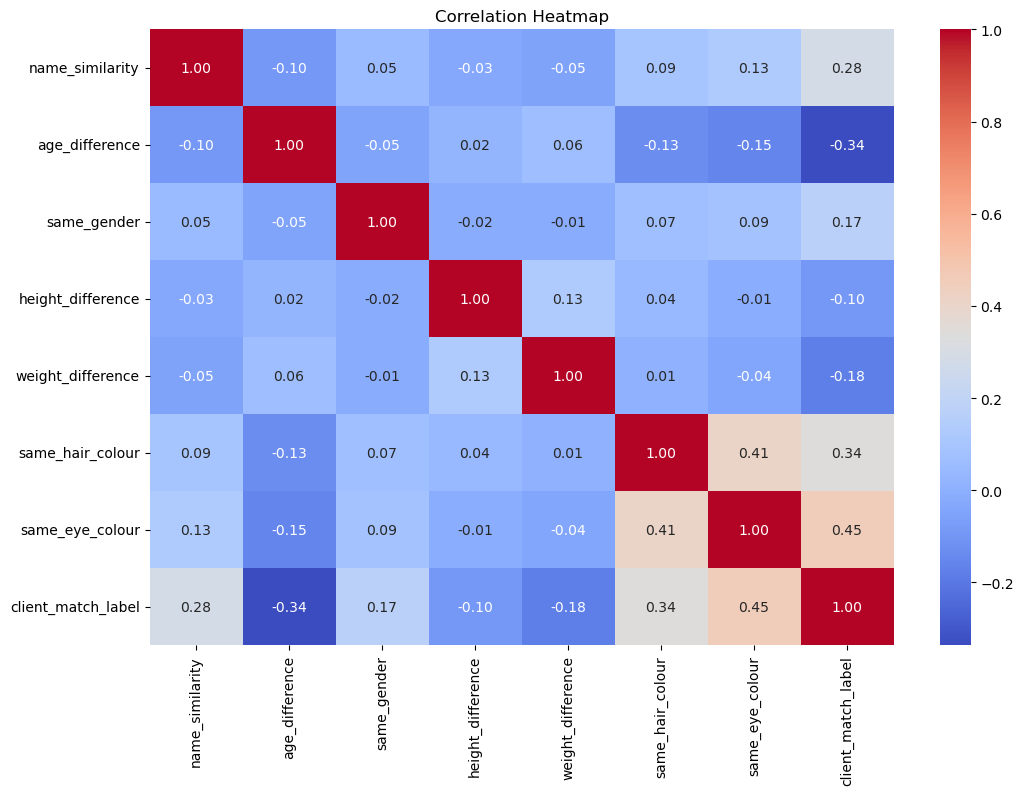

In [16]:
print("""
Observation:
- There is very high correlation between name_similarity and client_match_label
- Not much correlation between age_difference and client_match_label as expected (the logic of the synthetic dataset was that if the name AND age are similar, where age is not more than 3 years apart, then it should lead to a match)
""")
# 1. Calculate the correlation matrix
corr_matrix = client_sanctions.corr(numeric_only=True)

# 2. Set up the plot
plt.figure(figsize=(12, 8))

# 3. Create the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap')
plt.show()


Observation:
- name similarity is slightly multimodal distributed. There's a possibility where labelling high and low name similarity may improve robustness of model however, we will leave it as of now
- the distribution of age, height and weight are right skewed. Will benefit from log transformation.



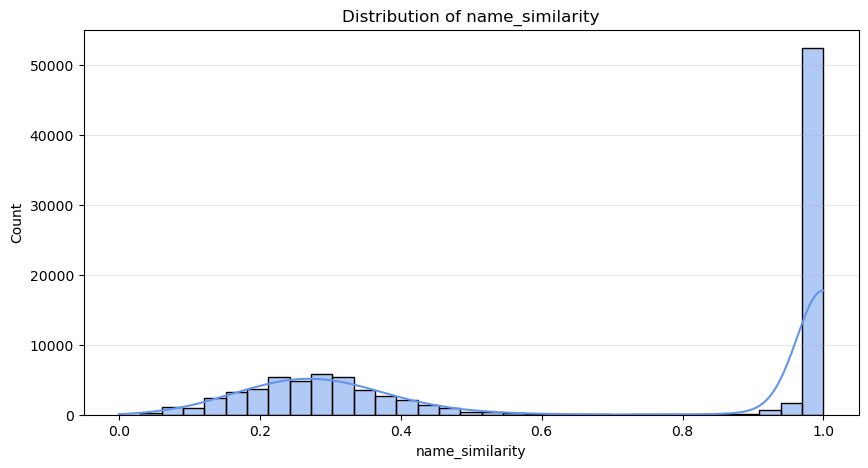

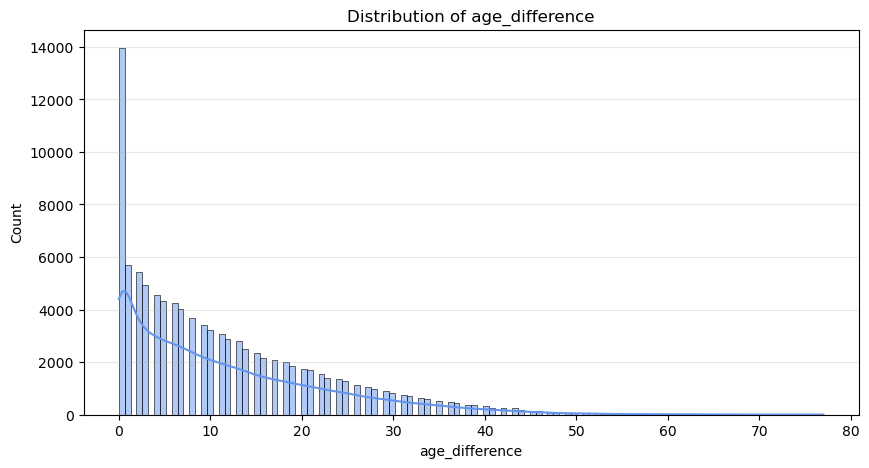

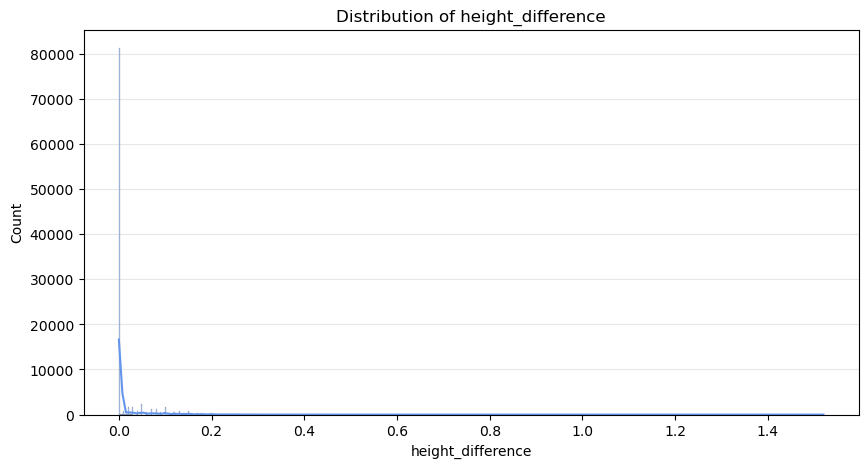

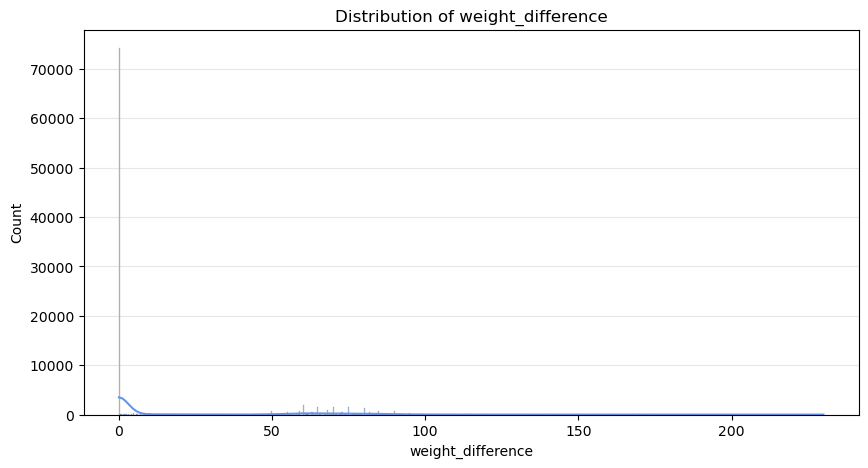

In [17]:
cols = [
    'name_similarity',
    'age_difference',
    'height_difference',
    'weight_difference'
]

def plot_dist_cont(data, numerical_cols):
    for col in numerical_cols:
        plt.figure(figsize=(10, 5))
        
        if pd.api.types.is_datetime64_any_dtype(data[col]):
            data_to_plot = data[col].dt.year.dropna()
            title = f'Yearly Distribution: {col}'
            xlabel = 'Year'
        else:
            data_to_plot = data[col].dropna().astype(float)
            title = f'Distribution of {col}'
            xlabel = col
    
        sns.histplot(data_to_plot, kde=True, color='cornflowerblue')
        plt.title(title)
        plt.xlabel(xlabel)
        plt.grid(axis='y', alpha=0.3)
        plt.show()

print("""
Observation:
- name similarity is slightly multimodal distributed. There's a possibility where labelling high and low name similarity may improve robustness of model however, we will leave it as of now
- the distribution of age, height and weight are right skewed. Will benefit from log transformation.
""")

plot_dist_cont(client_sanctions, cols)


Observation:
- Based on our logic, gender of the client and the sanctioned individual should match if the client is the sanctioned individual
- a lot of the hair and eye colours match even though we randomly assigned hair colour to the individual



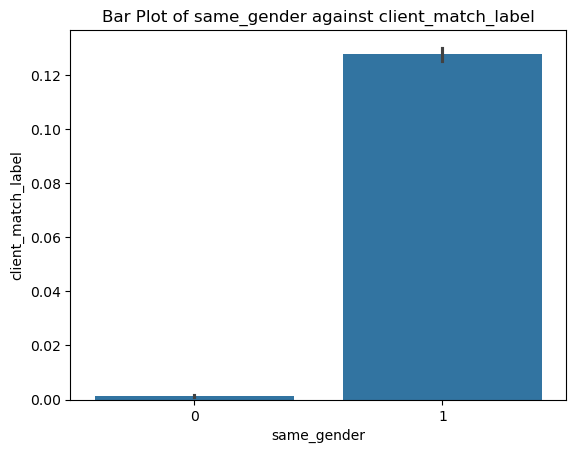

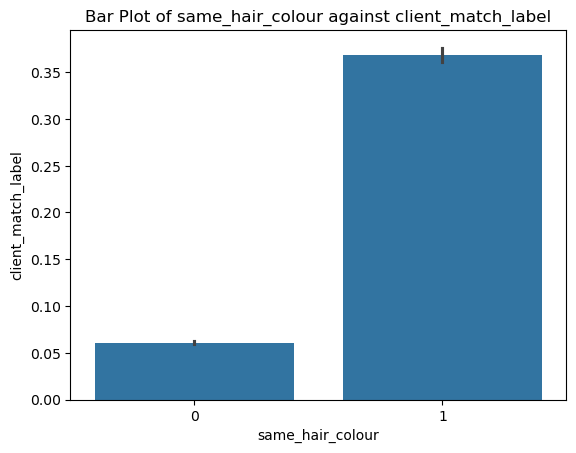

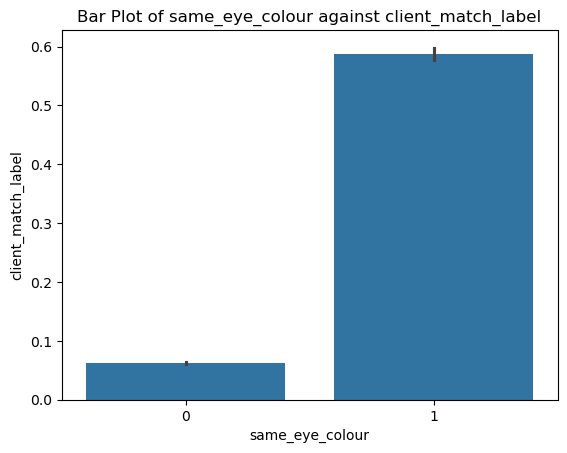

In [18]:
print("""
Observation:
- Based on our logic, gender of the client and the sanctioned individual should match if the client is the sanctioned individual
- a lot of the hair and eye colours match even though we randomly assigned hair colour to the individual
""")

x_columns = ['same_gender', 'same_hair_colour', 'same_eye_colour']
y = 'client_match_label'

for x in x_columns:
    sns.barplot(data=client_sanctions, x=x, y=y)

    # Add title and display
    plt.title(f"Bar Plot of {x} against {y}")
    plt.show()

## Helper Functions

In [19]:
# function for accuracy
def calculate_accuracy(y_test, y_pred):
    return accuracy_score(y_test, y_pred)

# function for precision
def calculate_precision(y_test, y_pred):
    tp = np.sum((y_test==1) & (y_pred ==1))
    fp = np.sum((y_test==0) & (y_pred ==1))
    return tp / (tp + fp)

# function for recall
def calculate_recall(y_test, y_pred):
    tp = np.sum((y_test==1) & (y_pred ==1))
    fn = np.sum((y_test==1) & (y_pred ==0))
    return tp / (tp + fn)

# function for true positive rate
def true_positive_rate(y_test, y_pred):
    tp = np.sum((y_test==1) & (y_pred ==1))
    fn = np.sum((y_test==1) & (y_pred ==0))
    return tp / (tp + fn)

# function for false positive
def false_positive_rate(y_test, y_pred):
    fp = np.sum((y_test == 0) & (y_pred == 1))
    tn = np.sum((y_test == 0) & (y_pred == 0))
    return fp / (fp + tn)

# function for auc
def calculate_auc(y_test, y_pred):
    return roc_auc_score(y_test, y_pred)

# function for f1 score
def calculate_f1(y_test, y_pred):
    return f1_score(y_test, y_pred)

# function for f2 score
def calculate_f2(y_test, y_pred):
    return fbeta_score(y_test, y_pred, beta=2.0, average='binary')

## Logistic Regression

C:\Users\Dian\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\Dian\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,0
F2-score,0.885554
F1-score,0.867333
accuracy,0.972941
precision,0.838575
recall,0.898133
true positive rate,0.898133
false positive rate,0.018887


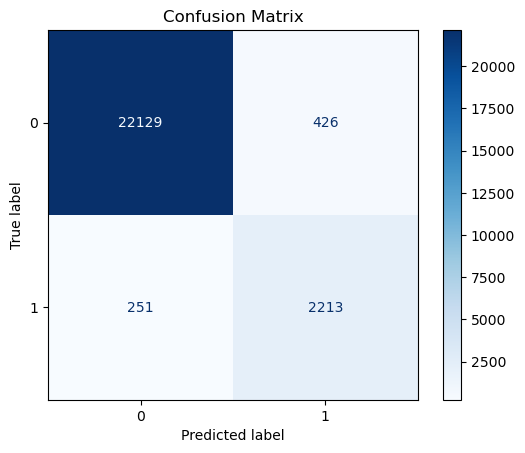

In [20]:
def local_train_test_split(df, target = 'client_match_label'):
    return model_selection.train_test_split(df.drop(target, axis=1), df[target], random_state=42)
X_train, X_test, y_train, y_test = local_train_test_split(client_sanctions)

logit = linear_model.LogisticRegression(l1_ratio=0, solver='saga', max_iter=500)

logit.fit(X_train, y_train)
y_pred = logit.predict(X_test)

# calculate accuracy
accuracy = calculate_accuracy(y_test, y_pred)
# calculate precision
prec = calculate_precision(y_test, y_pred)
# calculate recall
recall = calculate_recall(y_test, y_pred)
# calculate true positive rate
tpr = true_positive_rate(y_test, y_pred)
# calculate false positive rate
fpr = false_positive_rate(y_test, y_pred)
# calculate f1 score
f1 = calculate_f1(y_test, y_pred)
# calculate f2 score
f2 = calculate_f2(y_test, y_pred)

# display metrics
display(pd.DataFrame([f2, f1, accuracy, prec, recall, tpr, fpr], index=['F2-score', 'F1-score', 'accuracy', 'precision', 'recall', 'true positive rate', 'false positive rate']))

# display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

## Decision Tree

,0
F2-score,0.869785
F1-score,0.838420
accuracy,0.965506
precision,0.790887
recall,0.892032
true positive rate,0.892032
false positive rate,0.026301


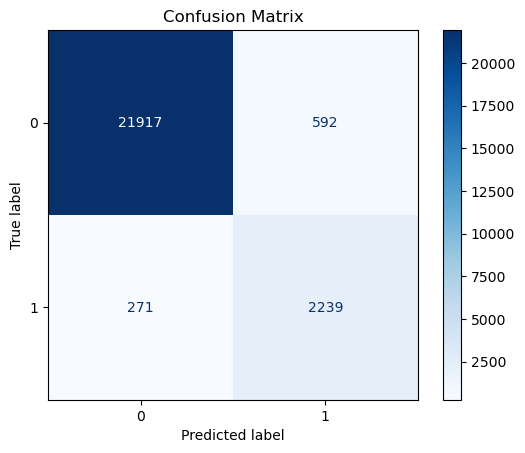

In [21]:
def local_train_test_split(df, target = 'client_match_label'):
    return model_selection.train_test_split(df.drop(target, axis=1), df[target], random_state=600)
X_train2, X_test2, y_train2, y_test2 = local_train_test_split(client_sanctions)

dt = DecisionTreeClassifier(max_depth=3, random_state=0)
dt.fit(X_train2, y_train2)

y_pred2 = dt.predict(X_test2)

# calculate accuracy
accuracy = calculate_accuracy(y_test2, y_pred2)
# calculate precision
prec = calculate_precision(y_test2, y_pred2)
# calculate recall
recall = calculate_recall(y_test2, y_pred2)
# calculate true positive rate
tpr = true_positive_rate(y_test2, y_pred2)
# calculate false positive rate
fpr = false_positive_rate(y_test2, y_pred2)
# calculate f1 score
f1 = calculate_f1(y_test2, y_pred2)
# calculate f2 score
f2 = calculate_f2(y_test2, y_pred2)

# display metrics
display(pd.DataFrame([f2, f1, accuracy, prec, recall, tpr, fpr], index=['F2-score', 'F1-score', 'accuracy', 'precision', 'recall', 'true positive rate', 'false positive rate']))

# display confusion matrix
cm = confusion_matrix(y_test2, y_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

## Random Forest

,0
F2-score,0.970779
F1-score,0.940575
accuracy,0.987450
precision,0.894207
recall,0.992016
true positive rate,0.992016
false positive rate,0.013059


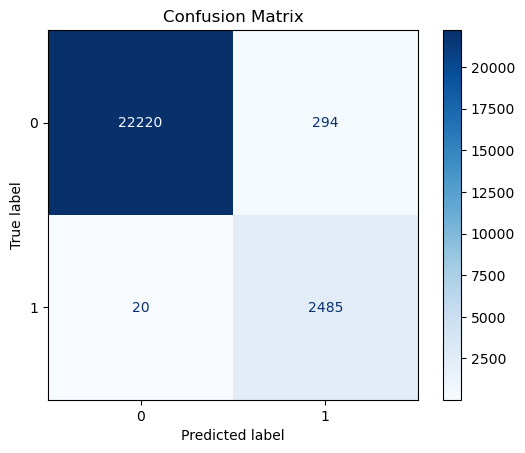

In [22]:
def local_train_test_split(df, target = 'client_match_label'):
    return model_selection.train_test_split(df.drop(target, axis=1), df[target], random_state=700)
X_train3, X_test3, y_train3, y_test3 = local_train_test_split(client_sanctions)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=700)
rf.fit(X_train3, y_train3)

y_pred3 = rf.predict(X_test3)

# calculate accuracy
accuracy = calculate_accuracy(y_test3, y_pred3)
# calculate precision
prec = calculate_precision(y_test3, y_pred3)
# calculate recall
recall = calculate_recall(y_test3, y_pred3)
# calculate true positive rate
tpr = true_positive_rate(y_test3, y_pred3)
# calculate false positive rate
fpr = false_positive_rate(y_test3, y_pred3)
# calculate f1 score
f1 = calculate_f1(y_test3, y_pred3)
# calculate f2 score
f2 = calculate_f2(y_test3, y_pred3)

# display metrics
display(pd.DataFrame([f2, f1, accuracy, prec, recall, tpr, fpr], index=['F2-score', 'F1-score', 'accuracy', 'precision', 'recall', 'true positive rate', 'false positive rate']))

# display confusion matrix
cm = confusion_matrix(y_test3, y_pred3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

## Check check

In [23]:
y_pred3

array([0, 1, 0, ..., 0, 0, 1], shape=(25019,))

In [24]:
y_test3

21376    0
7181     1
21123    0
81121    0
36732    0
        ..
93224    0
67777    0
37023    0
82386    0
52169    1
Name: client_match_label, Length: 25019, dtype: int64

In [25]:
test_concat = pd.concat([X_test3.reset_index(drop=True), y_test3.reset_index(drop=True)], axis = 1)
test_pred = pd.concat([test_concat, pd.Series(y_pred3, name='prediction')], axis=1)
wrong_pred = test_pred[test_pred['client_match_label'] != test_pred['prediction']]
wrong_pred[wrong_pred['prediction']==0]

,name_similarity,age_difference,same_gender,height_difference,weight_difference,same_hair_colour,same_eye_colour,client_match_label,prediction
2694,1.000000,0,0,0.000000,0.0,0,0,1,0
2790,1.000000,1,1,0.000000,0.0,0,0,1,0
3452,1.000000,1,1,0.000000,0.0,0,0,1,0
3484,1.000000,2,1,0.000000,0.0,0,0,1,0
4755,1.000000,2,1,0.000000,0.0,0,0,1,0
5328,1.000000,0,1,0.017616,0.0,0,0,1,0
5642,1.000000,0,1,0.014632,0.0,0,0,1,0
5663,1.000000,2,1,0.000000,0.0,0,0,1,0
5823,1.000000,0,1,0.022519,0.0,0,0,1,0
8712,1.000000,0,0,0.000000,0.0,0,0,1,0


In [40]:
wrong_pred['name_similarity'].unique()

array([1.        , 0.72727273])

In [41]:
wrong_pred[wrong_pred['prediction']==0]

,name_similarity,age_difference,same_gender,height_difference,weight_difference,same_hair_colour,same_eye_colour,client_match_label,prediction
2694,1.000000,0,0,0.000000,0.0,0,0,1,0
2790,1.000000,1,1,0.000000,0.0,0,0,1,0
3452,1.000000,1,1,0.000000,0.0,0,0,1,0
3484,1.000000,2,1,0.000000,0.0,0,0,1,0
4755,1.000000,2,1,0.000000,0.0,0,0,1,0
5328,1.000000,0,1,0.017616,0.0,0,0,1,0
5642,1.000000,0,1,0.014632,0.0,0,0,1,0
5663,1.000000,2,1,0.000000,0.0,0,0,1,0
5823,1.000000,0,1,0.022519,0.0,0,0,1,0
8712,1.000000,0,0,0.000000,0.0,0,0,1,0


In [26]:
test_concat = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis = 1)
test_pred = pd.concat([test_concat, pd.Series(y_pred, name='prediction')], axis=1)
wrong_pred = test_pred[test_pred['client_match_label'] != test_pred['prediction']]
wrong_pred[wrong_pred['prediction']==0]

,name_similarity,age_difference,same_gender,height_difference,weight_difference,same_hair_colour,same_eye_colour,client_match_label,prediction
194,0.971429,2,1,0.000000,0.0,0,0,1,0
244,0.875000,1,1,0.000000,0.0,0,0,1,0
402,0.976744,1,1,0.000000,0.0,0,0,1,0
532,0.937500,3,1,0.027283,0.0,0,0,1,0
557,0.967742,1,1,0.000000,0.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...
24021,0.971429,2,1,0.015897,0.0,1,0,1,0
24314,0.972973,1,1,0.000000,0.0,0,0,1,0
24383,1.000000,0,1,0.000000,75.0,1,1,1,0
24907,1.000000,1,1,0.000000,0.0,0,0,1,0


In [29]:
test_concat = pd.concat([X_test5.reset_index(drop=True), y_test5.reset_index(drop=True)], axis = 1)
test_pred = pd.concat([test_concat, pd.Series(y_pred5, name='prediction')], axis=1)
wrong_pred = test_pred[test_pred['client_match_label'] != test_pred['prediction']]
wrong_pred[wrong_pred['prediction']==0]

,name_similarity,age_difference,same_gender,height_difference,weight_difference,same_hair_colour,same_eye_colour,client_match_label,prediction
393,1.000000,2,1,0.000000,0.0,0,0,1,0
658,1.000000,1,1,0.000000,0.0,0,0,1,0
790,1.000000,3,1,0.008776,0.0,1,1,1,0
1256,0.812500,2,1,0.000000,0.0,0,0,1,0
1452,1.000000,2,1,0.016380,0.0,1,1,1,0
2195,1.000000,0,0,0.000000,0.0,0,0,1,0
2245,1.000000,0,0,0.000000,0.0,0,0,1,0
3990,1.000000,2,1,0.015051,0.0,0,0,1,0
5847,1.000000,3,1,0.000000,0.0,0,0,1,0
6748,0.818182,2,1,0.000000,0.0,0,0,1,0


## XGBoost

C:\Users\Dian\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:06:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,0
F2-score,0.966543
F1-score,0.933002
accuracy,0.985971
precision,0.881992
recall,0.990276
true positive rate,0.990276
false positive rate,0.014500


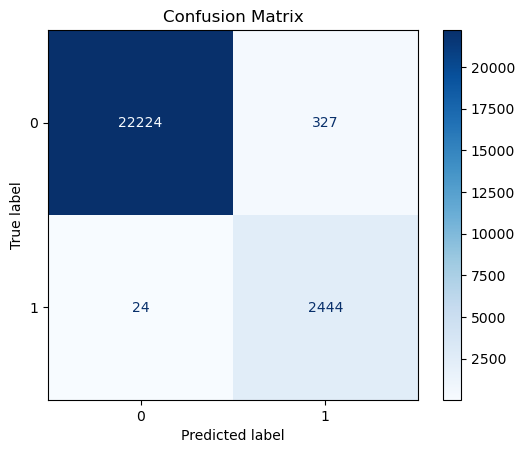

In [28]:
def local_train_test_split(df, target = 'client_match_label'):
    return model_selection.train_test_split(df.drop(target, axis=1), df[target], random_state= 612)
X_train5, X_test5, y_train5, y_test5 = local_train_test_split(client_sanctions)

xgboost = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, use_label_encoder=False, eval_metric='mlogloss')
xgboost.fit(X_train5, y_train5)

# 5. Predict
y_pred5 = xgboost.predict(X_test5)

# calculate accuracy
accuracy = calculate_accuracy(y_test5, y_pred5)
# calculate precision
prec = calculate_precision(y_test5, y_pred5)
# calculate recall
recall = calculate_recall(y_test5, y_pred5)
# calculate true positive rate
tpr = true_positive_rate(y_test5, y_pred5)
# calculate false positive rate
fpr = false_positive_rate(y_test5, y_pred5)
# calculate f1 score
f1 = calculate_f1(y_test5, y_pred5)
# calculate f2 score
f2 = calculate_f2(y_test5, y_pred5)

# display metrics
display(pd.DataFrame([f2, f1, accuracy, prec, recall, tpr, fpr], index=['F2-score', 'F1-score', 'accuracy', 'precision', 'recall', 'true positive rate', 'false positive rate']))

# display confusion matrix
cm = confusion_matrix(y_test5, y_pred5)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

## Ensemble (Voting)

C:\Users\Dian\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\Dian\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Dian\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:41:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,0
F2-score,0.972783
F1-score,0.940524
accuracy,0.987569
precision,0.891265
recall,0.995547
true positive rate,0.995547
false positive rate,0.013304


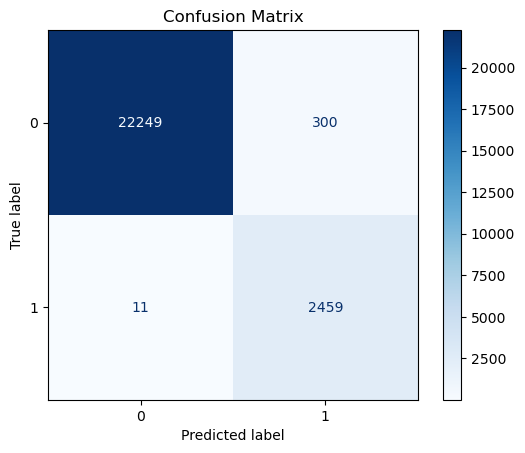

In [44]:
def local_train_test_split(df, target = 'client_match_label'):
    return model_selection.train_test_split(df.drop(target, axis=1), df[target], random_state= 0)
X_train6, X_test6, y_train6, y_test6 = local_train_test_split(client_sanctions)

# Initialize base models
clf1 = logit
clf2 = rf
clf3 = xgboost

# Create the Ensemble
ensemble_model = VotingClassifier(
    estimators=[('lr', clf1), ('rf', clf2), ('xgb', clf3)],
    voting='soft' 
)

# Fit the ensemble
ensemble_model.fit(X_train6, y_train6)

# 5. Predict
y_pred6 = ensemble_model.predict(X_test6)

# calculate accuracy
accuracy = calculate_accuracy(y_test6, y_pred6)
# calculate precision
prec = calculate_precision(y_test6, y_pred6)
# calculate recall
recall = calculate_recall(y_test6, y_pred6)
# calculate true positive rate
tpr = true_positive_rate(y_test6, y_pred6)
# calculate false positive rate
fpr = false_positive_rate(y_test6, y_pred6)
# calculate f1 score
f1 = calculate_f1(y_test6, y_pred6)
# calculate f2 score
f2 = calculate_f2(y_test6, y_pred6)

# display metrics
display(pd.DataFrame([f2, f1, accuracy, prec, recall, tpr, fpr], index=['F2-score', 'F1-score', 'accuracy', 'precision', 'recall', 'true positive rate', 'false positive rate']))

# display confusion matrix
cm = confusion_matrix(y_test6, y_pred6)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

## Ensemble (Stacking)

,0
F2-score,0.969108
F1-score,0.933848
accuracy,0.985611
precision,0.880457
recall,0.994131
true positive rate,0.994131
false positive rate,0.015359


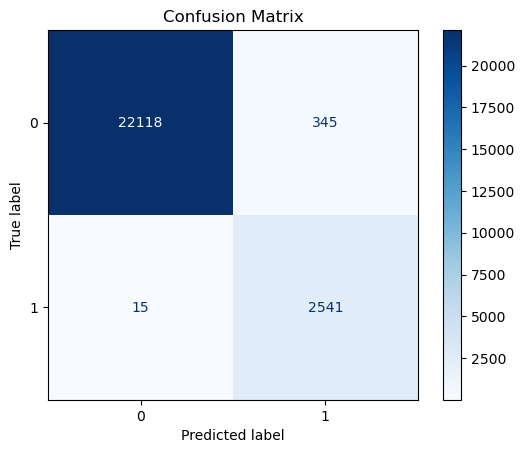

In [45]:
def local_train_test_split(df, target = 'client_match_label'):
    return model_selection.train_test_split(df.drop(target, axis=1), df[target], random_state= 30)
X_train7, X_test7, y_train7, y_test7 = local_train_test_split(client_sanctions)

# Define your base learners
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', xgb.XGBClassifier(random_state=42)),
    ('lr', linear_model.LogisticRegression(max_iter=1000))
]

# Define the Meta-Learner (The model that combines them)
# Logistic Regression is the industry standard for the final layer
meta_learner = linear_model.LogisticRegression()

# Create the Stacking Ensemble
stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5, # It uses internal cross-validation to train the meta-learner
    n_jobs=-1
)

# Fit it just like a regular model
stacking_model.fit(X_train7, y_train7)

# Fit the ensemble
stacking_model.fit(X_train7, y_train7)

# 5. Predict
y_pred7 = ensemble_model.predict(X_test7)

# calculate accuracy
accuracy = calculate_accuracy(y_test7, y_pred7)
# calculate precision
prec = calculate_precision(y_test7, y_pred7)
# calculate recall
recall = calculate_recall(y_test7, y_pred7)
# calculate true positive rate
tpr = true_positive_rate(y_test7, y_pred7)
# calculate false positive rate
fpr = false_positive_rate(y_test7, y_pred7)
# calculate f1 score
f1 = calculate_f1(y_test7, y_pred7)
# calculate f2 score
f2 = calculate_f2(y_test7, y_pred7)

# display metrics
display(pd.DataFrame([f2, f1, accuracy, prec, recall, tpr, fpr], index=['F2-score', 'F1-score', 'accuracy', 'precision', 'recall', 'true positive rate', 'false positive rate']))

# display confusion matrix
cm = confusion_matrix(y_test7, y_pred7)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

## K-Fold

In [46]:
# 1. Split client_sanctions into X and y
X = client_sanctions.drop(columns = ['client_match_label'])
y = client_sanctions['client_match_label']

# 2. Create the scoring dictionary
scoring_metrics = {
    'f2': make_scorer(calculate_f2),
    'f1': make_scorer(calculate_f1),
    'accuracy': make_scorer(calculate_accuracy),
    'precision': make_scorer(calculate_precision),
    'recall': make_scorer(calculate_recall),
    'tpr': make_scorer(true_positive_rate),
    'fpr': make_scorer(false_positive_rate)
}

# Define your models
models = {
    "Logistic Regression": logit,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgboost,
    "Ensemble (Voting)": ensemble_model,
    "Ensemble (Stacking)": stacking_model
}

# Use the scoring_metrics dictionary from the previous step
all_model_results = []

for name, model in models.items():
    print(f"Running K-Fold for {name}...")
    
    cv_results = cross_validate(
        model, X, y, 
        cv=5, 
        scoring=scoring_metrics,
        n_jobs=-1 # Uses all CPU cores to speed it up
    )
    
    # Store the mean of each metric
    row = {'Model': name}
    for metric in scoring_metrics.keys():
        row[metric] = cv_results[f'test_{metric}'].mean()
    
    all_model_results.append(row)

# 5. Compare everything in a clean Table
results_df = pd.DataFrame(all_model_results)
display(results_df)

Running K-Fold for Logistic Regression...
Running K-Fold for Decision Tree...
Running K-Fold for Random Forest...
Running K-Fold for XGBoost...
Running K-Fold for Ensemble (Voting)...
Running K-Fold for Ensemble (Stacking)...


,Model,f2,f1,accuracy,precision,recall,tpr,fpr
0,Logistic Regression,0.889058,0.869402,0.972880,0.838519,0.902668,0.902668,0.019319
1,Decision Tree,0.875567,0.841485,0.966095,0.790232,0.899870,0.899870,0.026547
2,Random Forest,0.970807,0.938517,0.986979,0.889245,0.993605,0.993605,0.013757
3,XGBoost,0.970170,0.937565,0.986770,0.887859,0.993205,0.993205,0.013945
4,Ensemble (Voting),0.970818,0.938009,0.986860,0.888016,0.994005,0.994005,0.013934
5,Ensemble (Stacking),0.970549,0.938450,0.986970,0.889448,0.993205,0.993205,0.013723


## Visualisation & Feature Importance

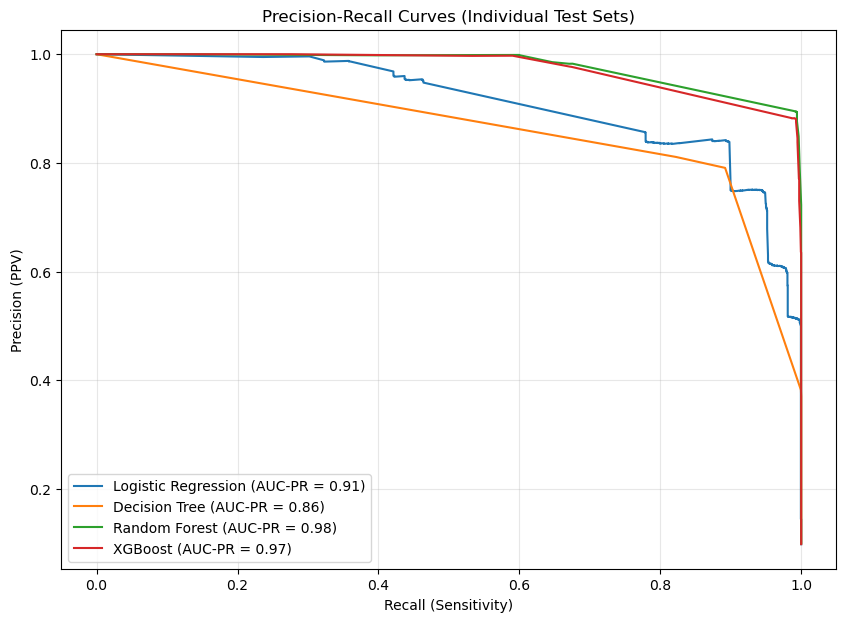

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, precision_recall_curve

def plot_multimodel_pr(models_dict, test_data_dict):
    """
    Plots Precision-Recall curves for multiple models.
    """
    plt.figure(figsize=(10, 7))
    
    for name, model in models_dict.items():
        X_test_curr, y_test_curr = test_data_dict[name]
        
        # 1. Get prediction scores/probabilities
        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_test_curr)[:, 1]
        else:
            probs = model.decision_function(X_test_curr)
            
        # 2. Calculate Precision and Recall
        precision, recall, _ = precision_recall_curve(y_test_curr, probs)
        
        # 3. Calculate Area Under Curve (AUC-PR)
        # Using average_precision_score is often preferred for PR curves
        pr_auc = auc(recall, precision) 
        
        plt.plot(recall, precision, label=f'{name} (AUC-PR = {pr_auc:.2f})')

    # Formatting the plot
    plt.xlabel('Recall (Sensitivity)')
    plt.ylabel('Precision (PPV)')
    plt.title('Precision-Recall Curves (Individual Test Sets)')
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.show()

models = {
    "Logistic Regression": logit,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgboost
    # "Ensemble (Voting)": ensemble_model,
    # "Ensemble (Stacking)": stacking_model
}
test_data_dict = {
    "Logistic Regression": (X_test, y_test), 
    "Decision Tree": (X_test2, y_test2),
    "Random Forest": (X_test3, y_test3),
    "XGBoost": (X_test5, y_test5)
    # "Ensemble (Voting)": (X_test6, y_test6),
    # "Ensemble (Stacking)": (X_test7, y_test7)
}
plot_multimodel_pr(models, test_data_dict)

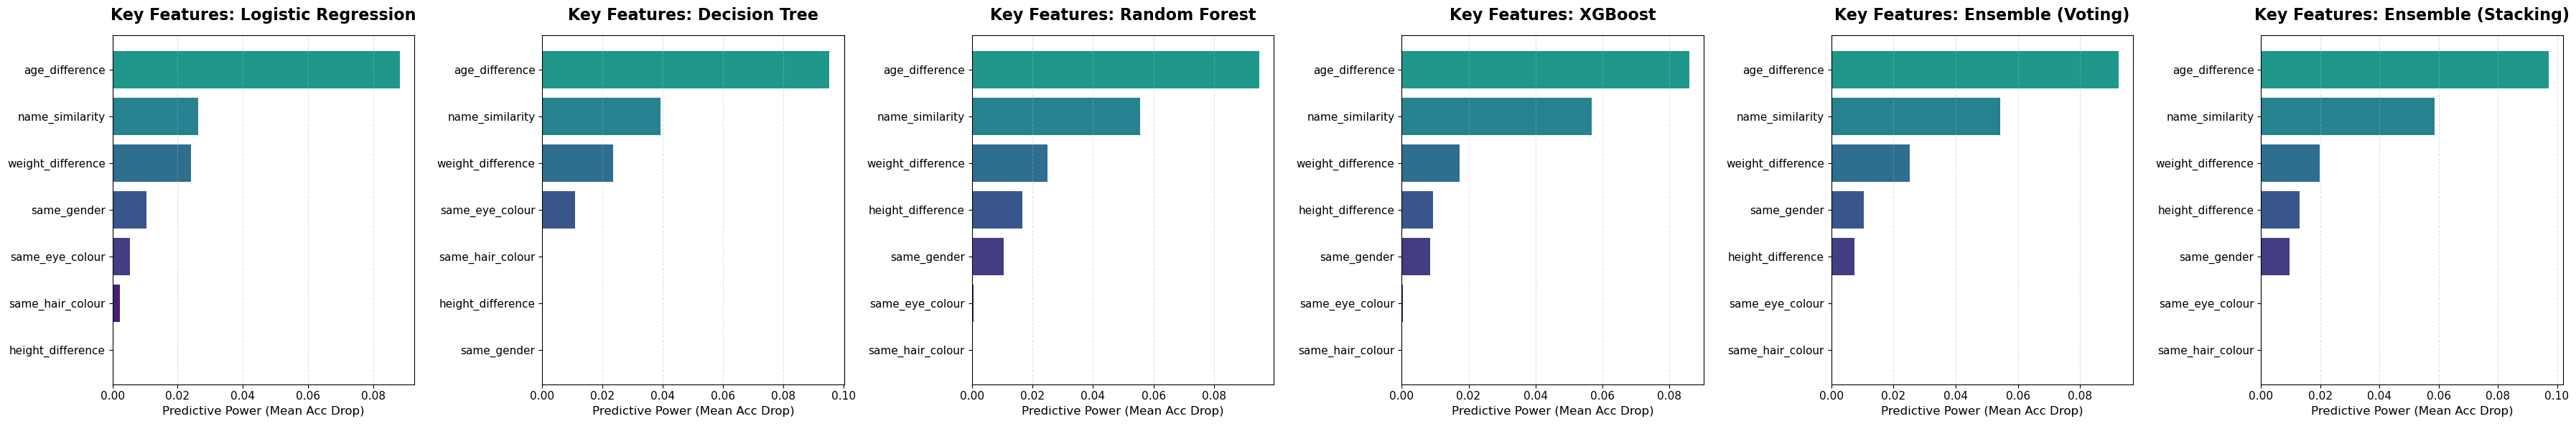

In [34]:
from sklearn.inspection import permutation_importance

def plot_all_feature_importances(models_dict, test_data_dict, top_n=10):
    num_models = len(models_dict)
    fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 6))
    
    # Handle cases where there's only one model (axes won't be an array)
    if num_models == 1:
        axes = [axes]

    for i, (name, model) in enumerate(models_dict.items()):
        X_test_curr, y_test_curr = test_data_dict[name]
        
        # Calculate Permutation Importance
        result = permutation_importance(
            model, X_test_curr, y_test_curr, n_repeats=5, random_state=42
        )
        
        # Organize data
        feature_names = X_test_curr.columns if hasattr(X_test_curr, 'columns') else [f"F{j}" for j in range(X_test_curr.shape[1])]
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': result.importances_mean
        }).sort_values(by='Importance', ascending=True).tail(top_n)

        # Use a nice color map (e.g., 'viridis' or 'coolwarm')
        colors = plt.cm.viridis(np.linspace(0, 0.8, top_n))
        
        axes[i].barh(importance_df['Feature'], importance_df['Importance'], color=colors)
        axes[i].set_title(f'Key Features: {name}', fontsize=16, fontweight='bold', pad=15)
        axes[i].set_xlabel('Predictive Power (Mean Acc Drop)', fontsize=12)
        axes[i].tick_params(axis='both', labelsize=11)
        axes[i].grid(axis='x', linestyle='--', alpha=0.4)

    plt.subplots_adjust(wspace=0.4) # Add space between the two charts
    plt.tight_layout()
    plt.show()

plot_all_feature_importances(models, test_data_dict)

In [262]:
results_df.to_csv('../outputs/pillar3_model_results.csv', index=False)

## Output models

In [256]:
with open('../outputs/pillar3_logistic_regression.pkl', 'wb') as file:
    pickle.dump(logit, file)

In [257]:
with open('../outputs/pillar3_decision_tree.pkl', 'wb') as file:
    pickle.dump(dt, file)

In [258]:
with open('../outputs/pillar3_random_forest.pkl', 'wb') as file:
    pickle.dump(rf, file)

In [259]:
with open('../outputs/pillar3_xgboost.pkl', 'wb') as file:
    pickle.dump(xgboost, file)

In [260]:
with open('../outputs/pillar3_ensemble_voting.pkl', 'wb') as file:
    pickle.dump(ensemble_model, file)

In [261]:
with open('../outputs/pillar3_ensemble_stacking.pkl', 'wb') as file:
    pickle.dump(stacking_model, file)